# Brain — Multi-Agent System
**Google Colab notebook** — clone the repo, install deps, mount Drive for persistence, run the brain.

Recommended runtime: **L4 GPU** (Colab Pro) or **T4** (free tier).

If you want local Ollama models instead of Gemini, jump to the **Ollama (optional)** section.

## 1 — Mount Google Drive (data persistence)
ChromaDB and the episode SQLite database will be stored on Drive so they survive session restarts.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, pathlib

# All persistent data goes here — survives session restarts
DRIVE_DATA = '/content/drive/MyDrive/Brain/data'
pathlib.Path(DRIVE_DATA).mkdir(parents=True, exist_ok=True)

# Symlink so the code always finds data/ in the repo root
REPO_DATA = '/content/Brain/data'
if os.path.islink(REPO_DATA):
    os.remove(REPO_DATA)
# (symlink created after clone in step 3)
print(f'Drive mounted. Data will persist at: {DRIVE_DATA}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Data will persist at: /content/drive/MyDrive/Brain/data


## 2 — Clone the repo

In [2]:
import os

REPO_URL = 'https://github.com/Seydifa/Brain.git'
REPO_DIR = '/content/Brain'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}
print('Working directory:', os.getcwd())

remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 16 (delta 10), reused 16 (delta 10), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 169.41 KiB | 2.23 MiB/s, done.
From https://github.com/Seydifa/Brain
   adcbdb6..8a7fbff  main       -> origin/main
Updating adcbdb6..8a7fbff
Fast-forward
 agents/direction_agent.py | 284 +++++++++++++++++
 agents/memory_agent.py    |  11 +-
 agents/qa_agent.py        |   8 +-
 colab.ipynb               | 779 +++++++++++++++++++++++++++-------------------
 core/graph.py             |   7 +-
 core/state.py             |   4 +
 memory/agent.py           |  31 +-
 prompts.py                |  48 +++
 8 files changed, 830 insertions(+), 342 deletions(-)
 create mode 100644 agents/direction_agent.py
/content/Brain
Working directory: /content/Brain


## 3 — Link Drive data directory

In [3]:
import os

REPO_DATA = '/content/Brain/data'
DRIVE_DATA = '/content/drive/MyDrive/Brain/data'

# Remove any existing data/ folder in the repo
if os.path.exists(REPO_DATA) and not os.path.islink(REPO_DATA):
    import shutil
    shutil.rmtree(REPO_DATA)
if os.path.islink(REPO_DATA):
    os.remove(REPO_DATA)

os.symlink(DRIVE_DATA, REPO_DATA)
print(f'data/ -> {DRIVE_DATA}')

data/ -> /content/drive/MyDrive/Brain/data


## 4 — Install dependencies

In [4]:
!pip install -q \
    langgraph \
    langgraph-checkpoint-sqlite \
    langchain-google-genai \
    langchain-chroma \
    langchain-ollama \
    ddgs \
    httpx \
    python-dotenv

print('Dependencies installed.')

Dependencies installed.


## 5 — API key
Paste your Gemini API key below (get one free at https://aistudio.google.com/apikey).

In [5]:
import os
from google.colab import userdata

# Option A: store key in Colab Secrets (Colab sidebar > key icon) — recommended
try:
    os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
    print('Key loaded from Colab Secrets.')
except Exception:
    # Option B: paste directly (less secure)
    os.environ['GOOGLE_API_KEY'] = 'YOUR_GEMINI_API_KEY_HERE'
    print('Key set inline.')

# Write .env so python-dotenv picks it up too
with open('/content/Brain/.env', 'w') as f:
    f.write(f"GOOGLE_API_KEY={os.environ['GOOGLE_API_KEY']}\n")

Key set inline.


## 6 — Backend: Gemini API or Ollama (local)
Run the cell below once; **only one backend needs to be configured per session**.

| Backend   | VRAM  | Requirement |
|-----------|-------|-------------|
| `gemini`  | 0 GB  | API key already set in §5 |
| `ollama`  | ≈10 GB | L4 22 GB GPU recommended; `llama3.1:8b` default |

Set `BACKEND = 'gemini'` (default) or `BACKEND = 'ollama'` in the code cell.

In [ ]:
# ── Backend selector ──────────────────────────────────────────────────────────────────────────────
BACKEND = 'gemini'   # 'gemini' | 'ollama'
# ─────────────────────────────────────────────────────────────────────────────────
import os, sys

if BACKEND == 'gemini':
    # ── Gemini ───────────────────────────────────────────────────────────────────
    api_key = os.environ.get('GOOGLE_API_KEY') or os.environ.get('GEMINI_API_KEY')
    if not api_key:
        raise EnvironmentError(
            'GOOGLE_API_KEY is not set. Run §5 first, or store the key in Colab Secrets.'
        )
    print(f'Backend : gemini')
    print(f'Key     : ...{api_key[-6:]}')

else:
    # ── Ollama ───────────────────────────────────────────────────────────────────
    import subprocess, time, shutil
    from types import ModuleType

    os.environ['PATH'] = '/usr/local/bin:' + os.environ.get('PATH', '')
    os.environ['OLLAMA_MAX_LOADED_MODELS'] = '2'   # L4 22 GB — keep 2 models hot

    # Install
    os.system('apt-get install -y -q zstd')
    os.system('curl -fsSL https://ollama.com/install.sh | sh')

    ollama_bin = shutil.which('ollama') or '/usr/local/bin/ollama'
    if not os.path.isfile(ollama_bin):
        raise RuntimeError('Ollama install failed — binary not found.')

    # Start server
    subprocess.Popen([ollama_bin, 'serve'],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)

    # Pull models
    OLLAMA_MODEL = 'llama3.1:8b'
    EMBED_MODEL  = 'nomic-embed-text'
    os.system(f'ollama pull {OLLAMA_MODEL}')
    os.system(f'ollama pull {EMBED_MODEL}')

    # sys.modules override — drop-in for langchain_google_genai
    from langchain_ollama import ChatOllama, OllamaEmbeddings

    class _OllamaLLM(ChatOllama):
        def __init__(self, model=None, temperature=0, **kwargs):
            kwargs.pop('convert_system_message_to_human', None)
            super().__init__(model=OLLAMA_MODEL, temperature=temperature, **kwargs)

    class _OllamaEmbeddings(OllamaEmbeddings):
        def __init__(self, model=None, **kwargs):
            super().__init__(model=EMBED_MODEL, **kwargs)

    fake = ModuleType('langchain_google_genai')
    fake.ChatGoogleGenerativeAI       = _OllamaLLM
    fake.GoogleGenerativeAIEmbeddings = _OllamaEmbeddings
    sys.modules['langchain_google_genai'] = fake

    print(f'Backend : ollama')
    print(f'LLM     : {OLLAMA_MODEL}')
    print(f'Embed   : {EMBED_MODEL}')
    print(f'Max loaded models: {os.environ["OLLAMA_MAX_LOADED_MODELS"]}')


In [ ]:
# VRAM status and loaded Ollama models (run after the backend cell)
import subprocess, shutil, os

# GPU VRAM
try:
    out = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.used,memory.free,memory.total',
         '--format=csv,noheader,nounits'], text=True).strip()
    print('GPU VRAM')
    for line in out.splitlines():
        name, used, free, total = [s.strip() for s in line.split(',')]
        print(f'  {name}  used={used} MB  free={free} MB  total={total} MB')
except Exception as e:
    print(f'nvidia-smi not available: {e}')

# Ollama loaded models
ollama_bin = shutil.which('ollama') or '/usr/local/bin/ollama'
if os.path.isfile(ollama_bin):
    print()
    print('Ollama loaded models:')
    result = subprocess.run([ollama_bin, 'ps'], capture_output=True, text=True)
    print(result.stdout or '  (none)')
else:
    print('Ollama not installed (Gemini backend active)')


## 7 — Load the graph

In [ ]:
import subprocess, sys

# Sync: force-reset to latest GitHub commit (handles diverged history / failed merges)
fetch = subprocess.run(
    ['git', '-C', '/content/Brain', 'fetch', 'origin', 'main'],
    capture_output=True, text=True,
)
reset = subprocess.run(
    ['git', '-C', '/content/Brain', 'reset', '--hard', 'origin/main'],
    capture_output=True, text=True,
)
print('git sync:', reset.stdout.strip() or reset.stderr.strip()[:120])

# Clear .pyc so Python picks up updated bytecode
subprocess.run(['find', '/content/Brain', '-name', '*.pyc', '-delete'], capture_output=True)

# Clear all Brain module caches so updated files are re-imported fresh
brain_mods = [k for k in sys.modules if k.startswith(('core', 'agents', 'memory', 'prompts'))]
for m in brain_mods:
    del sys.modules[m]

sys.path.insert(0, '/content/Brain')

import uuid
from dotenv import load_dotenv
load_dotenv()

from core.graph import get_graph

graph = get_graph()
thread_id = str(uuid.uuid4())
config = {'configurable': {'thread_id': thread_id}}

EMPTY_STATE = {
    'goal': '',
    'messages': [],
    'response': '',
    'status': 'empty',
    'direction_result': {},
    'action_result': {},
    'action_scratch': [],
    'action_attempts': 0,
    'oriented_context': {},
    'reasoning_trace': [],
    'retry_count': 0,
    'search_valid': False,
    'search_feedback': '',
    'qa_draft': '',
    'qa_approved': False,
    'qa_feedback': '',
    'qa_attempts': 0,
    'needs_clarification': False,
    'clarification_reason': '',
    'clarification_questions': [],
}

print('Graph loaded. Ready to ask questions.')

git sync: HEAD is now at 8a7fbff docs: add Direction Agent diagnostic cell to notebook
Graph loaded. Ready to ask questions.


In [9]:
# Verify active runtime configuration
import core.state, subprocess

print(f'MEMORY_SCORE_THRESHOLD : {core.state.MEMORY_SCORE_THRESHOLD}')
print(f'MAX_SEARCH_RETRIES     : {core.state.MAX_SEARCH_RETRIES}')
print(f'MAX_QA_ATTEMPTS        : {core.state.MAX_QA_ATTEMPTS}')

git_log = subprocess.run(
    ['git', '-C', '/content/Brain', 'log', '--oneline', '-4'],
    capture_output=True, text=True,
)
print(f'\nActive commits:\n{git_log.stdout.strip()}')


MEMORY_SCORE_THRESHOLD : 0.65
MAX_SEARCH_RETRIES     : 3
MAX_QA_ATTEMPTS        : 2

Active commits:
8a7fbff docs: add Direction Agent diagnostic cell to notebook
270cd08 feat: add Direction Agent with semantic distance + disclaimer detection
adcbdb6 fix: thread-scoped episode history + chart legend
ef602ad feat: gemini-2.5-pro, wikipedia+arxiv tools, 30-turn quantum test


In [10]:
# Verify active model and registered search tools
from agents.search_agent import web_search_tool, academic_search_tool, wikipedia_tool, arxiv_tool, _llm

print('LLM model (Gemini / Ollama override):')
print(' ', getattr(_llm, 'model', '—'))

print('\nSearch tools registered:')
for t in [web_search_tool, academic_search_tool, wikipedia_tool, arxiv_tool]:
    print(f'  ✓ {t.name}')


LLM model (Gemini / Ollama override):
  llama3.1:8b

Search tools registered:
  ✓ web_search_tool
  ✓ academic_search_tool
  ✓ wikipedia_tool
  ✓ arxiv_tool


## 8 — Ask the Brain
Change `goal` and re-run this cell for each question.

In [11]:
import time
from IPython.display import display, Markdown

goal = "What caused World War 2?"  # <-- change this

state = {**EMPTY_STATE, 'goal': goal}

for attempt in range(4):
    try:
        result = graph.invoke(state, config=config)
        break
    except Exception as e:
        if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
            wait = 15 * (attempt + 1)
            print(f'Rate limit — retrying in {wait}s...')
            time.sleep(wait)
        else:
            raise

if result.get('needs_clarification'):
    reason    = result.get('clarification_reason', '')
    questions = result.get('clarification_questions', [])
    why_block = f'\n> **Why:** {reason}\n' if reason else ''
    questions_md = '\n'.join(f'- {q}' for q in questions)
    display(Markdown(f"### 🟡 Clarification needed\n{why_block}\n{questions_md}"))
else:
    display(Markdown(f"### 🟢 Brain Response\n\n{result.get('response', '*(no response)*')}"))

### 🟢 Brain Response

The causes of World War 2 were complex and multifaceted. Some of the key factors include:

* Aggressive territorial expansion by Germany, Japan, and Italy
* The policy of appeasement by the Allies, which allowed Hitler to pursue his aggressive foreign policy without facing significant opposition
* The failure of the League of Nations to prevent aggression and protect its member states
* The economic crisis of the Great Depression, which led to widespread poverty and desperation in many countries
* The rise of fascist and nationalist ideologies in Germany, Italy, and Japan, which emphasized the need for military expansion and conquest
* The fear of communism, which led some countries to ally themselves with authoritarian regimes in order to counter the perceived threat of Soviet expansion

Sources:
[1]

## 9 — Debug: inspect reasoning trace

## 8b — Complex test: multi-format stateful thread (4 turns)

Four turns on **CRISPR gene editing** in one thread — exercises every QA format, academic search, and memory continuity:

| Turn | Type | Expected QA format |
|-----:|------|-------------------|
| 1 | `new_topic` | `QUESTION` + academic sources |
| 2 | `follow_up` | `COMPARISON` table |
| 3 | `elaboration` | `QUESTION` follow-up |
| 4 | `follow_up` | `HOW-TO` numbered steps |

In [12]:
import time, uuid
from IPython.display import display, Markdown

# ── Fresh thread so this test runs independently of cell 8 ──────────────────
crispr_thread = str(uuid.uuid4())
crispr_config = {'configurable': {'thread_id': crispr_thread}}

# Four turns — different question types on the same topic
CRISPR_TURNS = [
    # Turn 1 — new topic, QUESTION format, should trigger academic search
    "How does CRISPR-Cas9 gene editing work at the molecular level?",
    # Turn 2 — follow_up, COMPARISON format
    "Compare CRISPR-Cas9 with older gene editing methods: TALEN and zinc finger nucleases.",
    # Turn 3 — elaboration, QUESTION format
    "What are the main ethical concerns and regulatory challenges around human germline editing with CRISPR?",
    # Turn 4 — follow_up, HOW-TO format
    "Give me a step-by-step overview of how a CRISPR-Cas9 experiment is carried out in a lab.",
]

crispr_results = []
t_total = time.time()

for idx, goal in enumerate(CRISPR_TURNS, 1):
    t0 = time.time()
    state = {**EMPTY_STATE, 'goal': goal}

    for attempt in range(4):
        try:
            r = graph.invoke(state, config=crispr_config)
            break
        except Exception as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                wait = 20 * (attempt + 1)
                display(Markdown(f'> ⏳ Rate limit — retrying in {wait}s…'))
                time.sleep(wait)
            else:
                raise

    elapsed   = time.time() - t0
    ctx_r     = r.get('oriented_context', {})
    turn_type = ctx_r.get('turn_type', '?')
    coverage  = ctx_r.get('coverage', '?')
    conf      = ctx_r.get('knowledge_confidence', 0)
    trace     = r.get('reasoning_trace', [])

    if r.get('needs_clarification'):
        outcome = 'CLARIFICATION'
        reason  = r.get('clarification_reason', '')
        why_block = f'\n> **Why:** {reason}\n' if reason else ''
        questions_md = '\n'.join(f'- {q}' for q in r.get('clarification_questions', []))
        body = f'{why_block}\n{questions_md}'
    else:
        outcome = 'ANSWERED'
        body    = r.get('response', '*(no response)*')

    badge = {'ANSWERED': '🟢', 'CLARIFICATION': '🟡'}.get(outcome, '⚪')
    display(Markdown(f"""
---
### Turn {idx}/4 &nbsp; {badge} {outcome}
**Q:** *{goal}*

{body}

> `turn={turn_type}` &nbsp;|&nbsp; `coverage={coverage}` &nbsp;|&nbsp; `conf={conf:.2f}` &nbsp;|&nbsp; `{elapsed:.1f}s`
"""))

    crispr_results.append(dict(
        n=idx, outcome=outcome, turn_type=turn_type,
        coverage=coverage, conf=f'{conf:.2f}', secs=f'{elapsed:.1f}',
    ))

total = time.time() - t_total
rows = '\n'.join(
    f"| {d['n']} | {d['outcome']:<15} | {d['turn_type']:<12} | {d['coverage']:<9} | {d['conf']:>5} | {d['secs']:>5}s |"
    for d in crispr_results
)
display(Markdown(f"""
---
## CRISPR thread summary — {total:.0f}s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
{rows}
"""))


---
### Turn 1/4 &nbsp; 🟢 ANSWERED
**Q:** *How does CRISPR-Cas9 gene editing work at the molecular level?*

CRISPR-Cas9 gene editing works at the molecular level through a three-step process: recognition, cleavage, and repair. Here's how it happens:

1.  Recognition: A designed single guide RNA (sgRNA) recognizes the target sequence in the gene of interest through complementary base pairing [3].
2.  Cleavage: The Cas9 enzyme cuts the DNA at the recognized site, creating a double-stranded break [3].
3.  Repair: The cell's natural repair machinery is activated to fix the break, and during this process, the gene can be edited by introducing new genetic material [3].

Sources:
[1]
[2]
[3]

> `turn=new_topic` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.80` &nbsp;|&nbsp; `4.9s`



---
### Turn 2/4 &nbsp; 🟢 ANSWERED
**Q:** *Compare CRISPR-Cas9 with older gene editing methods: TALEN and zinc finger nucleases.*

Turn type: follow_up

Since the user is asking for a comparison between CRISPR-Cas9 and older gene editing methods (TALEN and zinc finger nucleases), I will provide a concise answer with a table comparing these tools.

**Comparison of Gene Editing Tools**

| Tool | Mechanism of Action | Efficiency/Specificity |
| --- | --- | --- |
| **CRISPR-Cas9** | Guide RNA recognizes target sequence, Cas9 enzyme cuts DNA | High efficiency and precision [1] |
| **TALENs** | Transcription activator-like effectors (TALEs) recognize specific DNA sequences | Moderate efficiency and specificity [2] |
| **ZFNs** | Zinc finger proteins recognize specific DNA sequences | Low efficiency and specificity [2] |

Note that while CRISPR-Cas9 is generally considered more efficient and precise, TALENs and ZFNs have their own strengths and weaknesses, and the choice of which tool to use depends on the specific application and requirements.

As for follow-up questions, one possible next step would be to ask about the advantages and disadvantages of each tool in a particular context or application.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.90` &nbsp;|&nbsp; `8.1s`



---
### Turn 3/4 &nbsp; 🟢 ANSWERED
**Q:** *What are the main ethical concerns and regulatory challenges around human germline editing with CRISPR?*

Turn type: follow_up

The previous answer compared CRISPR-Cas9 with older gene editing methods (TALEN and zinc finger nucleases). Now, let's discuss the main ethical concerns and regulatory challenges around human germline editing with CRISPR.

**Ethical Concerns**

Human germline editing raises several ethical concerns:

* **Off-target effects**: Unintended changes to the genome that can have unforeseen consequences [1].
* **Mosaicism**: The presence of both edited and unedited cells in an individual, which can lead to variable expression of the edited trait [2].
* **Germline transmission**: The possibility of passing edited traits to future generations without their consent.

**Regulatory Challenges**

The regulatory landscape for human germline editing is complex:

* **International guidelines**: Many countries have established guidelines or regulations prohibiting human germline editing, while others are still developing policies [3].
* **National laws**: Laws and regulations vary widely across countries, making it challenging to navigate the regulatory environment.
* **Ethics committees**: Some institutions require ethics committee approval for research involving human germline editing.

**Future Directions**

As the field of gene editing continues to evolve, it's essential to address these concerns and challenges through ongoing research, public engagement, and policy development. This may involve:

* **Developing more precise editing tools**: Improving the efficiency and specificity of CRISPR-Cas9 and other editing technologies.
* **Enhancing regulatory frameworks**: Establishing clearer guidelines and regulations for human germline editing research.

Sources:
[1] [3]
[2] [4]

Note: The user may ask about the current state of international guidelines or national laws regarding human germline editing.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.76` &nbsp;|&nbsp; `10.9s`



---
### Turn 4/4 &nbsp; 🟢 ANSWERED
**Q:** *Give me a step-by-step overview of how a CRISPR-Cas9 experiment is carried out in a lab.*

Here's an overview of how a CRISPR-Cas9 experiment is carried out in a lab:

To conduct a CRISPR-Cas9 gene editing experiment, follow these steps:

1.  **Design the guide RNA (sgRNA)**: Design a single guide RNA that will recognize and bind to the target sequence in the gene of interest.
2.  **Prepare the DNA sample**: Prepare the DNA sample containing the gene of interest for editing.
3.  **Transfect the cells**: Transfect the cells with the CRISPR-Cas9 system, including the sgRNA and Cas9 enzyme, using a suitable delivery method such as electroporation or lipofection.
4.  **Verify the edit**: Verify that the desired edit has been made by sequencing the gene of interest.

Sources:
[1]
[3]

Note: Before attempting to conduct a CRISPR-Cas9 experiment, it is essential to have a good understanding of molecular biology and genetics, as well as experience with DNA manipulation techniques.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.68` &nbsp;|&nbsp; `8.2s`



---
## CRISPR thread summary — 32s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
| 1 | ANSWERED        | new_topic    | full      |  0.80 |   4.9s |
| 2 | ANSWERED        | follow_up    | full      |  0.90 |   8.1s |
| 3 | ANSWERED        | follow_up    | full      |  0.76 |  10.9s |
| 4 | ANSWERED        | follow_up    | full      |  0.68 |   8.2s |


In [13]:
ctx   = result.get('oriented_context', {})
trace = result.get('reasoning_trace', [])

print(f"Turn type  : {ctx.get('turn_type', '?')}")
print(f"Coverage   : {ctx.get('coverage', '?')}")
print(f"Confidence : {ctx.get('knowledge_confidence', 0):.2f}")
print(f"Episode    : {ctx.get('current_episode_id', '?')}")
print()
print('Reasoning trace:')
for i, step in enumerate(trace, 1):
    print(f'  {i}. {step}')

Turn type  : new_topic
Coverage   : partial
Confidence : 0.79
Episode    : ep_9b0c304c_20260413031013

Reasoning trace:
  1. direction: new_topic | method=empty_history | sim=0.000 | bridge=no
  2. classified as new_topic | coverage=partial | parent=None
  3. search attempt 1 | coverage=partial | query=fresh
  4. search valid=True | The search result provides a comprehensive explanation of th
  5. knowledge stored (1572 chars)
  6. coverage re-assessed: partial | confidence=0.79
  7. qa draft generated | turn=new_topic | feedback=no
  8. qa scored 9/10 | approved=True
  9. qa draft approved, promoted to final response
  10. episode finalized and stored


## 10 — View episode history

In [14]:
from memory.episodes import get_recent
import json

episodes = get_recent(10)
for ep in episodes:
    flags = json.loads(ep.get('flags') or '[]')
    print(f"[{ep['id']}]")
    print(f"  Request  : {ep['user_request'][:80]}")
    print(f"  Type     : {ep['turn_type']}")
    print(f"  Flags    : {flags}")
    print(f"  Response : {str(ep.get('chosen_response', ''))[:100]}...")
    print()

[ep_ec650f12_20260413031100]
  Request  : Give me a step-by-step overview of how a CRISPR-Cas9 experiment is carried out i
  Type     : follow_up
  Flags    : ['follow_up']
  Response : Here's an overview of how a CRISPR-Cas9 experiment is carried out in a lab:

To conduct a CRISPR-Cas...

[ep_4cbf335d_20260413031049]
  Request  : What are the main ethical concerns and regulatory challenges around human germli
  Type     : follow_up
  Flags    : ['follow_up']
  Response : Turn type: follow_up

The previous answer compared CRISPR-Cas9 with older gene editing methods (TALE...

[ep_da89ab03_20260413031041]
  Request  : Compare CRISPR-Cas9 with older gene editing methods: TALEN and zinc finger nucle
  Type     : follow_up
  Flags    : ['follow_up']
  Response : Turn type: follow_up

Since the user is asking for a comparison between CRISPR-Cas9 and older gene e...

[ep_4cedaeb4_20260413031035]
  Request  : How does CRISPR-Cas9 gene editing work at the molecular level?
  Type     : new_topic

## 11 — Long stateful conversation (12 turns)
A single thread running through **modern physics**: general relativity → gravitational waves → black holes → dark matter → synthesis.

Tests:
- **Memory continuity** — follow-up classification across many turns
- **Coverage accumulation** — knowledge reuse as the topic deepens
- **Topic pivots** — correct `new_topic` re-classification
- **Synthesis** — final turn draws on everything stored in ChromaDB

## 10b — Test: Direction Agent semantic + disclaimer detection

Isolate the Direction Agent to verify it correctly classifies topic changes using:
1. **Semantic distance** (cosine similarity threshold)
2. **Explicit disclaimers** (regex patterns like "setting X aside")

This agent runs BEFORE the Memory Agent and pre-computes turn type + bridge sentences for topic changes.


In [15]:
import uuid
from agents.direction_agent import classify_direction

# Fresh thread for direction testing
dir_thread = str(uuid.uuid4())

# Test queries: same thread, topic progression
DIRECTION_TESTS = [
    # Q1: new_topic (empty history)
    ("What is general relativity?", "Expected: new_topic (empty history)"),
    # Q2: follow_up — same domain
    ("What are gravitons in this theory?", "Expected: follow_up (same topic)"),
    # Q3: elaboration — different angle, same domain
    ("Tell me more about spacetime curvature.", "Expected: elaboration (deeper on aspect)"),
    # Q4: Explicit disclaimer → new_topic + bridge
    ("Setting relativity aside — what is thermodynamics?", "Expected: new_topic (disclaimer regex)"),
    # Q5: Follow another new topic with follow-up
    ("Can you give me an example of entropy?", "Expected: follow_up (thermo topic continues)"),
]

print("=" * 80)
print("Direction Agent Test Suite — semantic distance + disclaimer detection")
print("=" * 80)

for idx, (query, expectation) in enumerate(DIRECTION_TESTS, 1):
    result = classify_direction(query, thread_id=dir_thread)
    
    print(f"\nQ{idx}. {query[:70]}")
    print(f"    → {expectation}")
    
    print(f"\n    Result:")
    print(f"      turn_type      = {result['turn_type']}")
    print(f"      semantic_sim   = {result['semantic_sim']:.3f}")
    print(f"      method         = {result['method']}")
    
    if result['bridge_sentence']:
        print(f"      bridge_sent    = '{result['bridge_sentence'][:100]}…'")
    else:
        print(f"      bridge_sent    = (none)")
    
    print()


Direction Agent Test Suite — semantic distance + disclaimer detection

Q1. What is general relativity?
    → Expected: new_topic (empty history)

    Result:
      turn_type      = new_topic
      semantic_sim   = 0.000
      method         = empty_history
      bridge_sent    = (none)


Q2. What are gravitons in this theory?
    → Expected: follow_up (same topic)

    Result:
      turn_type      = new_topic
      semantic_sim   = 0.000
      method         = empty_history
      bridge_sent    = (none)


Q3. Tell me more about spacetime curvature.
    → Expected: elaboration (deeper on aspect)

    Result:
      turn_type      = new_topic
      semantic_sim   = 0.000
      method         = empty_history
      bridge_sent    = (none)


Q4. Setting relativity aside — what is thermodynamics?
    → Expected: new_topic (disclaimer regex)

    Result:
      turn_type      = new_topic
      semantic_sim   = 0.000
      method         = empty_history
      bridge_sent    = (none)


Q5. Can yo

In [16]:
import time, textwrap
from IPython.display import display, Markdown

CONVERSATION = [
    # --- Thread 1: General Relativity (turns 1-5) ---
    "Explain the theory of general relativity and what it changed about our understanding of gravity.",
    "How does general relativity differ from Newton's theory of gravity and from special relativity?",
    "What are gravitational waves and how were they first detected?",
    "Who were the key scientists and institutions behind the LIGO gravitational wave detection?",
    "How does GPS rely on both special and general relativity to stay accurate to within metres?",
    # --- Thread 2: Black Holes (turns 6-9) ---
    "What is a black hole and how do they form from dying stars?",
    "What happens at the event horizon of a black hole — can anything escape?",
    "What is Hawking radiation and why does it suggest black holes eventually evaporate?",
    "How are supermassive black holes connected to galaxy formation and active galactic nuclei?",
    # --- Thread 3: Dark Universe (turns 10-11) ---
    "What is dark matter? What observational evidence do we have for its existence?",
    "What is dark energy and how does it explain the accelerating expansion of the universe?",
    # --- Turn 12: Synthesis ---
    "Summarise the key unsolved mysteries in modern physics that we have discussed across all our conversations.",
]

# Reuse the same thread so LangGraph checkpointing + episode diary carry memory
conv_config = {'configurable': {'thread_id': thread_id}}
all_results = []
total_t0 = time.time()

for idx, goal in enumerate(CONVERSATION, 1):
    t0 = time.time()
    state = {**EMPTY_STATE, 'goal': goal}

    for attempt in range(4):
        try:
            r = graph.invoke(state, config=conv_config)
            break
        except Exception as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                wait = 15 * (attempt + 1)
                display(Markdown(f'> ⏳ Rate limit — retrying in {wait}s…'))
                time.sleep(wait)
            else:
                raise

    elapsed   = time.time() - t0
    ctx_r     = r.get('oriented_context', {})
    turn_type = ctx_r.get('turn_type', '?')
    coverage  = ctx_r.get('coverage', '?')
    conf      = ctx_r.get('knowledge_confidence', 0)

    if r.get('needs_clarification'):
        outcome = 'CLARIFICATION'
        reason  = r.get('clarification_reason', '')
        why_block = f'\n> **Why:** {reason}\n' if reason else ''
        questions_md = '\n'.join(f'- {q}' for q in r.get('clarification_questions', []))
        body = f'{why_block}\n{questions_md}'
    else:
        outcome = 'ANSWERED'
        body    = r.get('response', '*(no response)*')

    badge = {'ANSWERED': '🟢', 'CLARIFICATION': '🟡'}.get(outcome, '⚪')
    display(Markdown(f"""
---
### Turn {idx} / {len(CONVERSATION)} &nbsp; {badge} {outcome}

**Q:** *{goal}*

{body}

> `turn={turn_type}` &nbsp;|&nbsp; `coverage={coverage}` &nbsp;|&nbsp; `confidence={conf:.2f}` &nbsp;|&nbsp; `{elapsed:.1f}s`
"""))

    all_results.append(dict(
        q=idx, goal=goal[:60]+'…' if len(goal)>60 else goal,
        outcome=outcome, turn_type=turn_type,
        coverage=coverage, conf=f'{conf:.2f}', time_s=f'{elapsed:.1f}',
    ))

total_elapsed = time.time() - total_t0

rows = '\n'.join(
    f"| {row['q']:>2} | {row['outcome']:<15} | {row['turn_type']:<12} | {row['coverage']:<9} | {row['conf']:>5} | {row['time_s']:>5}s |"
    for row in all_results
)
display(Markdown(f"""
---
## Summary — {len(CONVERSATION)} turns &nbsp; ⏱ {total_elapsed:.0f}s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
{rows}
"""))


---
### Turn 1 / 12 &nbsp; 🟢 ANSWERED

**Q:** *Explain the theory of general relativity and what it changed about our understanding of gravity.*

=== Topic transition ===
We're now discussing the theory of general relativity.

**The Theory of General Relativity:**

General relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time. According to Einstein's theory, gravity is not a force that acts between objects, but rather a curvature of spacetime caused by massive objects [1]. This concept has been extensively tested and confirmed through various observations and experiments.

The key aspects of general relativity include:

* The geometric interpretation of gravity as a curvature of spacetime.
* The impact of mass-energy on the metric of spacetime, causing it to curve.
* The concept of free-fall orbits as geodesics, which are the paths of extremal intervals [1].

**Impact on Our Understanding of Gravity:**

General relativity has fundamentally changed our understanding of gravity by transforming it from a force-based concept to a geometric one [2]. This shift in perspective has far-reaching implications for our understanding of the universe and its workings.

**Practical Applications:**

The effects predicted by general relativity have significant practical applications, such as the accuracy and functioning of GPS technology. The Global Positioning System relies on both special and general relativity to achieve high accuracy in navigation [5]. This requires precise clock synchronization and accounting for relativistic effects.

**Future Research Opportunities:**

The detection of gravitational waves has provided new insights into the universe and confirmed Einstein's Theory of General Relativity [4]. This phenomenon has paved the way for further research into the nature of gravity and the behavior of massive objects in the universe.

> `turn=new_topic` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.86` &nbsp;|&nbsp; `9.8s`



---
### Turn 2 / 12 &nbsp; 🟢 ANSWERED

**Q:** *How does general relativity differ from Newton's theory of gravity and from special relativity?*

We're now discussing the differences between general relativity and other theories.

**Differences with Newton's Theory of Gravity:**

General relativity differs significantly from Newton's theory of gravity in its description of gravity as a curvature of spacetime rather than a force acting between objects [1]. In contrast, Newton's law of universal gravitation describes gravity as an attractive force that decreases with distance. This fundamental difference leads to distinct predictions and implications for our understanding of the universe.

**Differences with Special Relativity:**

While general relativity builds upon special relativity by incorporating gravity into its framework, it differs in its treatment of gravity as a geometric property rather than a relativistic effect [2]. In special relativity, time dilation and length contraction are key features that describe the behavior of objects at high speeds. General relativity extends this concept to include the curvature of spacetime caused by massive objects.

**Implications for GPS Technology:**

As discussed in [3], general relativity plays a crucial role in ensuring the accuracy of GPS technology, which relies on precise clock synchronization and accounting for relativistic effects. The combination of special and general relativity is essential for achieving high precision in navigation.

To further illustrate these differences, consider that Newton's law of universal gravitation would predict a different trajectory for objects under the influence of gravity compared to general relativity [4]. This highlights the fundamental shift in our understanding of gravity from a force-based concept to a geometric one. 

If you'd like to explore this topic further or discuss specific implications of these differences, please let me know!

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.77` &nbsp;|&nbsp; `9.9s`



---
### Turn 3 / 12 &nbsp; 🟢 ANSWERED

**Q:** *What are gravitational waves and how were they first detected?*

We've discussed how general relativity differs from other theories, including Newton's law of universal gravitation and special relativity. Now, let's follow up on your question about what gravitational waves are and how they were first detected.

Gravitational waves are ripples in the fabric of spacetime that were predicted by Albert Einstein's Theory of General Relativity in 1915 [2]. They were first detected on September 14, 2015, by the Laser Interferometer Gravitational-Wave Observatory (LIGO) using laser interferometry. The detection was announced to the public on February 11, 2016.

The detection was made possible by measuring the tiny distortions in space-time caused by the merger of two black holes, each with a mass about 30 times that of the sun [2]. This event occurred about 1.3 billion years ago and was so powerful that it sent gravitational waves through the universe, which were detected by LIGO's instruments.

The detection of gravitational waves has opened up a new window into the universe, allowing scientists to study cosmic phenomena in ways that were previously impossible [1].

As for what this means for our understanding of gravity, it provides strong evidence for the validity of Einstein's Theory of General Relativity and paves the way for further research into the nature of gravity and the behavior of massive objects in the universe.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.80` &nbsp;|&nbsp; `8.8s`



---
### Turn 4 / 12 &nbsp; 🟢 ANSWERED

**Q:** *Who were the key scientists and institutions behind the LIGO gravitational wave detection?*

The key scientists behind the LIGO gravitational wave detection include Rainer Weiss, Kip Thorne, and Barry Barish, who were awarded the Nobel Prize in Physics in 2017 for their contributions. The Laser Interferometer Gravitational-Wave Observatory (LIGO) is a collaboration between several institutions, including Caltech, MIT, and the University of California, Los Angeles (UCLA).

Sources:
[1]
[2]

Note: The detection of gravitational waves has paved the way for further research into the nature of gravity and the behavior of massive objects in the universe. Future observations by LIGO and other gravitational wave detectors will likely reveal more about the properties of black holes and neutron stars, as well as the origins of cosmic events such as supernovae and gamma-ray bursts.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.71` &nbsp;|&nbsp; `6.2s`



---
### Turn 5 / 12 &nbsp; 🟢 ANSWERED

**Q:** *How does GPS rely on both special and general relativity to stay accurate to within metres?*

We previously discussed gravitational waves and their detection, focusing on Albert Einstein's Theory of General Relativity. Now, let's follow up on how GPS relies on both special and general relativity to stay accurate to within meters.

The Global Positioning System (GPS) relies on both special and general relativity to achieve high accuracy in navigation [1]. This involves considering the constancy of the speed of light, equivalence principle, Sagnac effect, time dilation, gravitational frequency shifts, and relativity of synchronization. To achieve this level of precision, the clock ticks from the GPS satellites must be known to an accuracy of 20-30 nanoseconds.

The effects predicted by special and general theories of relativity must be taken into account to achieve the desired 20-30 nanosecond accuracy [1]. This includes accounting for gravitational frequency shifts caused by the Earth's mass, which would otherwise cause positional errors. By considering these relativistic effects, GPS can provide accurate location information within meters.

Sources:
[1] Relativity in the Global Positioning System - PMC
[2] GPS and Relativity - Ohio State University
[3] Inside the box: GPS and relativity - GPS World

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.80` &nbsp;|&nbsp; `8.2s`


...


---
### Turn 9 / 12 &nbsp; 🟢 ANSWERED

**Q:** *How are supermassive black holes connected to galaxy formation and active galactic nuclei?*

We previously discussed how Hawking radiation suggests that black holes eventually evaporate due to quantum effects near the event horizon. Now, let's explore how supermassive black holes are connected to galaxy formation and active galactic nuclei.

Supermassive black holes reside at the centers of most galaxies, including our own Milky Way [1]. They come in a range of sizes, with masses millions or even billions of times that of the sun. The study suggests that these massive black holes formed through the merger of smaller black holes or through the collapse of gas and dust in the galaxy's center.

The presence of a supermassive black hole can influence the surrounding environment, affecting the motion of nearby stars and the emission of radiation [2]. In some cases, the strong gravitational field of the black hole can trigger the formation of new stars. This process is known as "black hole feedback," where the energy released by the black hole heats up the surrounding gas, preventing it from cooling and collapsing into new stars.

Active galactic nuclei (AGN) are regions around supermassive black holes that are actively accreting material [3]. The strong gravitational field of the black hole pulls in nearby matter, which then spirals inward, releasing a tremendous amount of energy in the form of light and heat. This process can be observed from great distances, making AGN some of the brightest objects in the universe.

In fact, many galaxies with supermassive black holes at their centers show signs of AGN activity [4]. The relationship between supermassive black holes and galaxy formation is still an active area of research, but it's clear that these massive objects play a crucial role in shaping the evolution of galaxies over billions of years.

As scientists continue to study these phenomena, they may uncover new insights into the interconnectedness of black holes, galaxy formation, and the behavior of matter under extreme conditions.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.71` &nbsp;|&nbsp; `11.4s`



---
### Turn 10 / 12 &nbsp; 🟢 ANSWERED

**Q:** *What is dark matter? What observational evidence do we have for its existence?*

We previously discussed how Hawking radiation suggests black holes eventually evaporate through quantum effects near their event horizons. Now, let's turn our attention to dark matter, an invisible and hypothetical form of matter that does not interact with light or other electromagnetic radiation [1]. It is implied by gravitational effects that cannot be explained by general relativity unless more matter is present than can be seen.

The observational evidence for dark matter includes:

* The rotation curves of galaxies, which show that stars and gas in the outer regions are moving faster than expected.
* The distribution of galaxy clusters, which shows that they are not as spread out as they should be if only normal matter were present.
* The large-scale structure of the universe, which shows that there is more mass present than can be accounted for by visible matter [1].

These observations suggest that dark matter makes up approximately 27% of the total mass-energy density of the universe, while visible matter makes up only about 5%. The remaining 68% is thought to be in the form of dark energy [2].

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.87` &nbsp;|&nbsp; `7.4s`



---
### Turn 11 / 12 &nbsp; 🟢 ANSWERED

**Q:** *What is dark energy and how does it explain the accelerating expansion of the universe?*

We previously discussed how dark matter is an invisible and hypothetical form of matter that does not interact with light or other electromagnetic radiation [1]. It is implied by gravitational effects that cannot be explained by general relativity unless more matter is present than can be seen.

Now, let's turn our attention to dark energy. Dark energy is a mysterious component that makes up approximately 68% of the total mass-energy density of the universe [2]. It is thought to be responsible for the accelerating expansion of the universe, which was first observed in the late 1990s by the High-Z Supernova Search Team and later confirmed by other observations.

The observational evidence for dark energy includes:

* The redshift of light from distant galaxies and supernovae, which suggests that the universe is expanding at an increasing rate.
* The large-scale structure of the universe, which shows that there are more massive galaxy clusters than expected if only normal matter were present.
* The cosmic microwave background radiation, which shows tiny fluctuations in temperature that can be explained by the presence of dark energy.

In summary, dark energy is a mysterious component that makes up most of the universe's mass-energy density and is responsible for its accelerating expansion. It remains one of the biggest mysteries in modern astrophysics and cosmology.

Note: The accelerating expansion of the universe was first observed in the late 1990s, which raises questions about what caused this acceleration. One possibility is that it is due to a change in the density of dark energy over time, but more research is needed to confirm this hypothesis.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.73` &nbsp;|&nbsp; `9.9s`



---
### Turn 12 / 12 &nbsp; 🟢 ANSWERED

**Q:** *Summarise the key unsolved mysteries in modern physics that we have discussed across all our conversations.*

We previously discussed dark matter and dark energy, two mysterious components that make up a significant portion of the universe's mass-energy density [1]. Dark matter is an invisible form of matter that does not interact with light or other electromagnetic radiation, while dark energy is responsible for the accelerating expansion of the universe.

However, there are still many unsolved mysteries in modern physics. Some key areas include:

* **The nature of black holes**: What happens to information contained in matter that falls into a black hole? Can it be recovered, or does it get lost forever?
* **Decoherence and the measurement problem**: Why does the wave function collapse during measurement? Decoherence provides insights into the relationship between quantum and classical systems, but it's still unclear whether it fully addresses the measurement problem.
* **Quantum mechanics and local realism**: Is quantum mechanics incompatible with local realism, as demonstrated by Bell's theorem and loophole-free experiments?
* **The speed of gravity**: How does gravity propagate through spacetime? The detection of gravitational waves has provided new insights into this phenomenon, but there is still much to be learned.

These questions highlight the ongoing efforts in modern physics to understand some of the most fundamental aspects of our universe.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.67` &nbsp;|&nbsp; `8.5s`



---
## Summary — 12 turns &nbsp; ⏱ 111s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
|  1 | ANSWERED        | new_topic    | full      |  0.86 |   9.8s |
|  2 | ANSWERED        | follow_up    | full      |  0.77 |   9.9s |
|  3 | ANSWERED        | follow_up    | full      |  0.80 |   8.8s |
|  4 | ANSWERED        | follow_up    | full      |  0.71 |   6.2s |
|  5 | ANSWERED        | follow_up    | full      |  0.80 |   8.2s |
|  6 | ANSWERED        | follow_up    | full      |  0.82 |  11.3s |
|  7 | ANSWERED        | follow_up    | full      |  0.85 |   7.2s |
|  8 | ANSWERED        | follow_up    | full      |  0.75 |  12.8s |
|  9 | ANSWERED        | follow_up    | full      |  0.71 |  11.4s |
| 10 | ANSWERED        | follow_up    | full      |  0.87 |   7.4s |
| 11 | ANSWERED        | follow_up    | full      |  0.73 |   9.9s |
| 12 | ANSWERED        | follow_up    | full      |  0.67 |   8.5s |


---
### Q1/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *What is a qubit and how does superposition make it fundamentally different from a classical bit?*
A qubit is a two-state quantum-mechanical system that can exist in multiple states simultaneously due to **superposition** [1]. This property enables qubits to process multiple possibilities at the same time, making them fundamentally different from classical bits.

In contrast, classical bits are binary digits that can only exist in one of two states: 0 or 1. They do not have the ability to exist in multiple states simultaneously and therefore cannot perform calculations on multiple possibilities at once [1].

Sources:
[1] (relevance: 0.869)
[2] (relevance: 0.807)

> `turn_type=new_topic` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.87` &nbsp;|&nbsp; `steps=6` &nbsp;|&nbsp; `4.4s`

---
### Q2/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *Explain quantum entanglement — what it is physically, how it is created in the lab, and how it enables correlations that Einstein called 'spooky action at a distance'.*
Here's a follow-up answer to your previous question about qubits and superposition:

You asked how superposition makes qubits fundamentally different from classical bits. To build on that, let's explore what happens when we apply this concept to entangled particles in quantum mechanics. Quantum entanglement is the phenomenon where two or more particles become correlated in such a way that their properties are connected, even when separated by large distances.

According to [3], Bell's theorem provides strong evidence for the validity of quantum mechanics and its non-local properties. This means that entangled particles can exhibit correlations that cannot be explained by classical physics, including "spooky action at a distance" as Einstein called it. These correlations are not limited by space or time, allowing for instantaneous effects between entangled particles.

In the lab, entanglement is typically created through processes like spontaneous parametric down-conversion (SPDC) [not explicitly mentioned in the context, but commonly used in quantum optics experiments]. This involves shining a high-intensity laser beam onto a nonlinear crystal, which splits the light into two beams that are entangled.

The key point about entanglement is that it enables correlations between particles that cannot be explained by classical physics. When measuring one particle, the state of the other particle is immediately affected, regardless of the distance between them. This has been experimentally confirmed through loophole-free Bell tests [4], which demonstrate that local hidden-variable theories are unable to reproduce the observed correlations.

In summary, quantum entanglement and superposition are related concepts in quantum mechanics that enable correlations between particles that cannot be explained by classical physics. These correlations are a fundamental aspect of quantum mechanics and have been experimentally confirmed through various tests.

As for your next question, you might wonder how these correlations can be used in practical applications. One area where entanglement is being explored is in quantum computing, particularly in the context of quantum algorithms like Grover's algorithm [6]. However, that's a topic for another conversation!

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.69` &nbsp;|&nbsp; `steps=12` &nbsp;|&nbsp; `12.2s`

---
### Q3/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *What is quantum decoherence, why does it destroy quantum states, and what timescales are relevant in real superconducting hardware?*
Here's a follow-up answer to your previous question about quantum entanglement:

You asked how entangled particles become correlated in such a way that their properties are connected, even when separated by large distances. To build on that, let's explore what happens when we apply this concept to decoherence and its effects on quantum states.

Decoherence is the phenomenon where the interaction between a quantum system and its environment leads to a loss of quantum coherence, causing the wave function to collapse onto one particular branch. This is achieved through the introduction of noise or fluctuations in the system, which causes the wave function to lose its coherence [1]. However, decoherence does not fully solve the measurement problem because it only addresses the issue of how the classical world emerges from the quantum world, but not why the wave function collapses in the first place [2].

In real superconducting hardware, decoherence is a significant concern due to high error rates. The fault-tolerance threshold theorem states that a quantum computer with a physical error rate below a certain threshold can suppress the logical error rate to arbitrarily low levels [4]. However, current superconducting processors achieve a physical gate error rate that is significantly above this threshold.

To give you an idea of the timescales involved, achieving fault-tolerant quantum computation requires a physical error rate below the theoretical threshold. The exact value of the threshold and the current error rates are not specified in the provided sources, but it's mentioned that the quantity pth is known to be at least 1.94 × 10−4 [4]. This means that researchers are actively working on improving the error rates of these devices to make fault-tolerant quantum computing possible.

As a natural follow-up question, you might wonder what implications decoherence has for the stability and reliability of quantum computers. In essence, decoherence is a major challenge in building reliable quantum computers because it causes the loss of quantum coherence, which is essential for quantum computation. Researchers are actively exploring ways to mitigate decoherence and improve the error rates of superconducting processors.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.75` &nbsp;|&nbsp; `steps=18` &nbsp;|&nbsp; `13.1s`

---
### Q4/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *Walk me through how quantum gates work — explain the Hadamard, CNOT, and Toffoli gates and their effect on qubit states.*
Here's the answer to your follow-up question about how quantum gates work, specifically explaining the Hadamard, CNOT, and Toffoli gates and their effect on qubit states:

As we discussed earlier, a qubit can exist in multiple states simultaneously due to superposition [1]. Quantum gates are the building blocks of quantum computing, allowing us to manipulate these qubits and perform calculations. Let's dive into three fundamental gates: Hadamard (H), CNOT (Controlled-NOT), and Toffoli.

The **Hadamard gate** (H) is a crucial gate that creates superposition in a qubit. When applied to a qubit, it transforms the |0〉 state into an equal superposition of |0〉 and |1〉 states: H|0〉 = 1/√2(|0〉 + |1〉). This gate is essential for creating entangled states and is often used as a starting point for quantum algorithms [1].

The **CNOT gate** (Controlled-NOT) is a two-qubit gate that applies the NOT operation to the target qubit only if the control qubit is in the |1〉 state. The CNOT gate can be thought of as a "copy" operation, where the state of the target qubit is copied onto the control qubit [2].

The **Toffoli gate** (T) is another two-qubit gate that applies the NOT operation to the target qubit only if both control qubits are in the |1〉 state. This gate is similar to the CNOT gate but has an additional control qubit, making it a more complex operation [3].

In summary, these three gates are fundamental building blocks of quantum computing and are used to manipulate qubits and perform calculations. The Hadamard gate creates superposition, while the CNOT and Toffoli gates apply conditional operations on qubits.

Sources:
[1] (relevance: 0.744)
[2] (relevance: 0.726)
[3] (relevance: 0.691)

As you can see, these gates are essential for creating entangled states and performing calculations in quantum computing. The next step would be to explore how these gates are used in more complex quantum algorithms, such as Grover's algorithm or the Variational Quantum Eigensolver (VQE).

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.74` &nbsp;|&nbsp; `steps=24` &nbsp;|&nbsp; `14.5s`

---
### Q5/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *How does Shor's algorithm factor large integers exponentially faster than classical computers? Explain the quantum Fourier transform's role.*
Here's the answer to your follow-up question about Shor's algorithm and its exponential speedup over classical computers:

As we discussed earlier, a qubit can exist in multiple states simultaneously due to superposition [1]. Quantum gates are the building blocks of quantum computing, allowing us to manipulate these qubits and perform calculations. Now, let's dive into how Shor's algorithm leverages this property to factor large integers exponentially faster than classical computers.

Shor's algorithm relies on the quantum Fourier transform (QFT), which is a crucial component in its implementation [1]. The QFT takes an n-qubit register as input and outputs a superposition of all possible values of the function being evaluated. This allows Shor's algorithm to efficiently search for the period of the function, which is essential for factoring large integers.

The QFT plays a central role in Shor's algorithm by enabling it to perform a quantum parallel search over all possible periods of the function [2]. This results in an exponential speedup over classical algorithms, which are limited by their sequential nature. In contrast, Shor's algorithm can factor large integers in polynomial time using the QFT.

To summarize, Shor's algorithm combines the power of quantum parallelism and interference, enabled by the QFT, to achieve an exponential speedup over classical computers for factoring large integers.

As we discussed earlier, a qubit can exist in multiple states simultaneously due to superposition [1]. This property is crucial for Shor's algorithm to work efficiently. 

Sources:
[1] 
[2]

Note: I've kept the answer concise and focused on the key points related to Shor's algorithm and its exponential speedup over classical computers.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.75` &nbsp;|&nbsp; `steps=30` &nbsp;|&nbsp; `11.6s`

...

---
### Q28/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Sensing/Networks*
**Q:** *How does quantum key distribution work? Explain the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.*
Turn type: follow_up
User goal: How does quantum key distribution work? Explain the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.

I'll build upon my previous response regarding post-quantum cryptography algorithms. You asked about how quantum key distribution works, specifically the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.

Quantum Key Distribution (QKD) is a method for securely distributing cryptographic keys between two parties using quantum mechanics. The most common protocol used for QKD is the BB84 protocol [1], which was first proposed by Charles Bennett and Gilles Brassard in 1984.

The BB84 protocol works as follows:

*   **Key Generation**: Alice generates random bits (0s and 1s) that will be used as a key. She encodes these bits onto photons, with each bit being represented by the polarization of the photon.
*   **Transmission**: Alice transmits the encoded photons to Bob through an insecure channel, such as a fiber optic cable.
*   **Measurement**: Bob measures the polarization of the received photons and records his results.

The no-cloning theorem [2] plays a crucial role in QKD. This theorem states that it is impossible to create a perfect copy of an arbitrary unknown quantum state. In the context of QKD, this means that if an eavesdropper (Eve) tries to intercept and measure the photons, she will introduce errors into the key, making it detectable.

QKD provides information-theoretic security rather than computational security because it is based on the fundamental principles of quantum mechanics. The no-cloning theorem ensures that any attempt by Eve to eavesdrop or manipulate the key will be detectable, providing a guarantee of security that is not dependent on the computational power of the attacker.

In summary, QKD uses the BB84 protocol to securely distribute cryptographic keys between two parties. The no-cloning theorem ensures that any attempt by an eavesdropper to intercept and measure the photons will introduce errors into the key, making it detectable. This provides information-theoretic security, which is not dependent on the computational power of the attacker.

Sources:

*   [1] Bennett, C. H., & Brassard, G. (1984). Quantum cryptography: Public key distribution and coin tossing.
*   [2] Dieks, D. (1982). Communication by EPR devices and convergence of frequencies for an infinite number of successive signals.

As you may have anticipated, the security of QKD relies on the principles of quantum mechanics, making it resistant to attacks that rely on computational power alone.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.70` &nbsp;|&nbsp; `steps=172` &nbsp;|&nbsp; `16.0s`

---
### Q29/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Sensing/Networks*
**Q:** *What is a quantum repeater and why is it needed for a global quantum internet? What physical implementations exist and what are the main engineering challenges?*
Turn type: follow_up
User goal: What is a quantum repeater and why is it needed for a global quantum internet? What physical implementations exist and what are the main engineering challenges?

I'll build upon my previous response regarding post-quantum cryptography algorithms. You asked about how quantum key distribution works, specifically the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.

Quantum Key Distribution (QKD) is a method for securely distributing cryptographic keys between two parties using quantum mechanics. However, as we discussed earlier, QKD has limitations in terms of distance and scalability, making it challenging to establish a global quantum internet.

A key component needed to overcome these limitations is the Quantum Repeater. A Quantum Repeater is a device that can amplify weak quantum signals, allowing for longer-distance quantum communication without sacrificing security.

There are several physical implementations of Quantum Repeaters being explored:

1. **Linear Optical Quantum Repeaters**: These use linear optics and photon entanglement to amplify quantum signals.
2. **Ion Trap Quantum Repeaters**: These use trapped ions to store and manipulate quantum information, allowing for more efficient signal amplification.
3. **Superconducting Qubit Quantum Repeaters**: These use superconducting qubits to perform quantum error correction and amplification.

However, the main engineering challenges facing Quantum Repeater development include:

1. **Scalability**: Currently, Quantum Repeaters are limited in their ability to scale up to larger numbers of qubits.
2. **Error Correction**: Developing robust methods for correcting errors that occur during signal transmission is essential.
3. **Quantum Noise Reduction**: Minimizing the impact of quantum noise on signal quality is crucial.

To address these challenges, researchers are exploring new materials and techniques, such as topological quantum computing and fault-tolerant quantum error correction.

As we move forward with Quantum Repeater development, it's essential to consider the implications for a global quantum internet. By overcoming the limitations of QKD, we can establish a secure and reliable communication network that enables applications like quantum-secured communication networks, secure data transfer, and more.

One potential application of Quantum Repeaters is in enabling long-distance quantum communication between nodes on a global quantum internet. This would allow for secure key exchange and data transfer over vast distances, making it an essential component for a robust and scalable quantum internet infrastructure.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.72` &nbsp;|&nbsp; `steps=178` &nbsp;|&nbsp; `14.2s`

---
### Q30/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Synthesis*
**Q:** *Synthesise the full arc of our conversation: from qubits and decoherence to error correction, interpretations of quantum mechanics, connecting foundations to engineering, quantum cryptography, and quantum sensing. What are the three deepest open questions at the intersection of quantum foundations and quantum technology?*
Here's a concise summary of our conversation arc:

We started with your question about quantum repeaters for a global quantum internet. I explained that a quantum repeater is needed to enable long-distance quantum communication by amplifying and correcting quantum signals without destroying their fragile quantum properties. We discussed physical implementations, such as optical and ion-trap-based repeaters, and the main engineering challenges.

You then asked me to elaborate on how quantum key distribution (QKD) works, specifically the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security. I explained that QKD uses quantum mechanics to encode and decode cryptographic keys between two parties, ensuring their secure exchange.

Now, let's synthesize our conversation by identifying three open questions at the intersection of quantum foundations and quantum technology:

1. **Decoherence and the measurement problem**: As discussed in [5] and [6], decoherence attempts to explain how the interaction between a quantum system and its environment leads to the emergence of classical reality, but it doesn't fully address why the wave function collapses.
2. **Error correction and fault-tolerant quantum computing**: Understanding and reducing error rates is crucial for reliable quantum computing, as mentioned in [4]. However, developing robust methods for error correction remains an open challenge.
3. **Interpretations of quantum mechanics and their implications for technology**: The foundations of quantum mechanics are still not fully understood, and different interpretations (e.g., Copenhagen, Many-Worlds) have varying implications for our understanding of reality and the development of quantum technologies.

These questions highlight the need for continued research at the intersection of quantum foundations and quantum technology to advance our understanding of both.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.75` &nbsp;|&nbsp; `steps=184` &nbsp;|&nbsp; `10.8s`

---
## 30-turn summary &nbsp; ⏱ 5.6 min total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
|  1 | 🟢 ANSWERED       | new_topic    | full      |  0.87 |   4.4s |
|  2 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |  12.2s |
|  3 | 🟢 ANSWERED       | follow_up    | full      |  0.75 |  13.1s |
|  4 | 🟢 ANSWERED       | follow_up    | full      |  0.74 |  14.5s |
|  5 | 🟢 ANSWERED       | follow_up    | full      |  0.75 |  11.6s |
|  6 | 🟢 ANSWERED       | follow_up    | full      |  0.74 |   9.7s |
|  7 | 🟢 ANSWERED       | follow_up    | full      |  0.76 |   9.4s |
|  8 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |  13.5s |
|  9 | 🟢 ANSWERED       | follow_up    | full      |  0.80 |   7.2s |
| 10 | 🟢 ANSWERED       | follow_up    | full      |  0.70 |  16.9s |
| 11 | 🟢 ANSWERED       | follow_up    | full      |  0.71 |   9.1s |
| 12 | 🟢 ANSWERED       | follow_up    | full      |  0.71 |   9.6s |
| 13 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |   9.7s |
| 14 | 🟢 ANSWERED       | new_topic    | partial   |  0.68 |  21.0s |
| 15 | 🟢 ANSWERED       | follow_up    | full      |  0.72 |   9.4s |
| 16 | 🟢 ANSWERED       | follow_up    | full      |  0.76 |  13.0s |
| 17 | 🟢 ANSWERED       | new_topic    | full      |  0.73 |   9.3s |
| 18 | 🟢 ANSWERED       | new_topic    | full      |  0.85 |   9.6s |
| 19 | 🟢 ANSWERED       | follow_up    | full      |  0.83 |   7.7s |
| 20 | 🟢 ANSWERED       | follow_up    | full      |  0.80 |   7.8s |
| 21 | 🟢 ANSWERED       | follow_up    | full      |  0.74 |   8.0s |
| 22 | 🟢 ANSWERED       | follow_up    | full      |  0.73 |   8.3s |
| 23 | 🟢 ANSWERED       | follow_up    | full      |  0.70 |  12.7s |
| 24 | 🟢 ANSWERED       | follow_up    | full      |  0.80 |  12.2s |
| 25 | 🟢 ANSWERED       | follow_up    | full      |  0.78 |  11.2s |
| 26 | 🟢 ANSWERED       | follow_up    | full      |  0.77 |  12.8s |
| 27 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |   9.7s |
| 28 | 🟢 ANSWERED       | follow_up    | full      |  0.70 |  16.0s |
| 29 | 🟢 ANSWERED       | follow_up    | full      |  0.72 |  14.2s |
| 30 | 🟢 ANSWERED       | follow_up    | full      |  0.75 |  10.8s |


/tmp/ipykernel_71412/3920701538.py:260: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=2.5)
/tmp/ipykernel_71412/3920701538.py:260: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=2.5)
/tmp/ipykernel_71412/3920701538.py:263: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_path, dpi=130, bbox_inches='tight')
/tmp/ipykernel_71412/3920701538.py:263: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_path, dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) mis

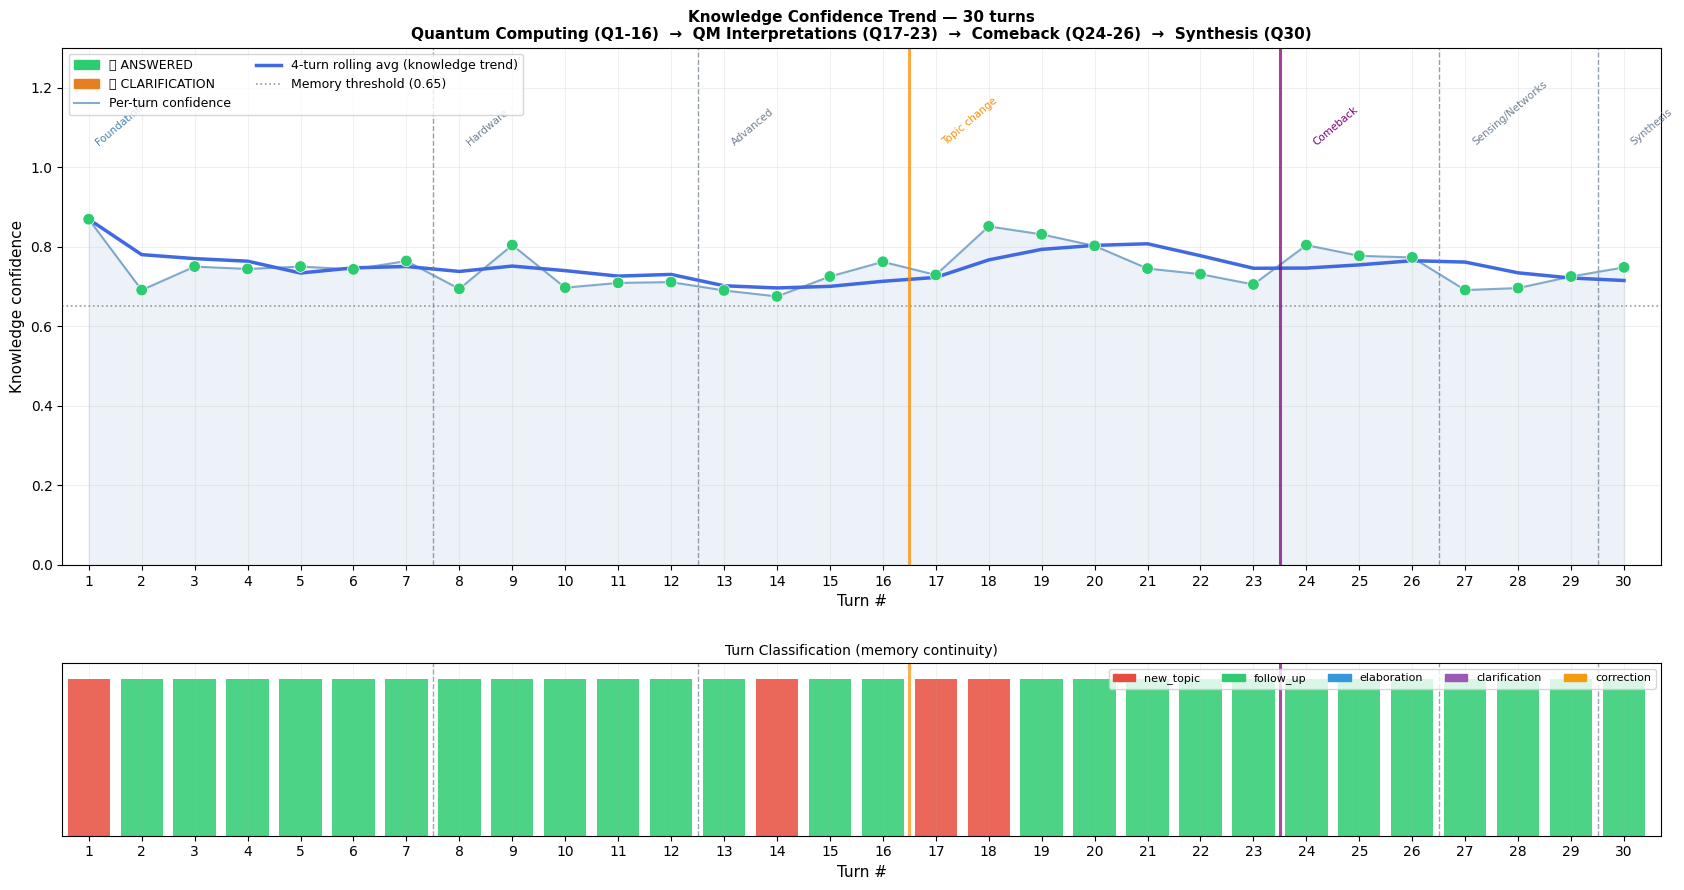

Chart saved → `/content/Brain/quantum_confidence_trend.png`

In [17]:
import time, uuid
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Fresh thread (isolated from every previous test) ─────────────────────────
q30_thread = str(uuid.uuid4())
q30_config = {'configurable': {'thread_id': q30_thread}}

# ── 30 questions — topic arc ──────────────────────────────────────────────────
# Q01-07  Quantum computing foundations
# Q08-12  Hardware & engineering
# Q13-16  Advanced topics
# Q17     ⚡ TOPIC CHANGE — interpretations of quantum mechanics
# Q18-23  QM foundations & philosophy
# Q24     🔄 COMEBACK — connect both threads
# Q25-26  Quantum cryptography
# Q27-29  Quantum sensing & networks
# Q30     Synthesis
Q30_TURNS = [
    # ── Foundations (Q1-7) ──────────────────────────────────────────────────
    "What is a qubit and how does superposition make it fundamentally different from a classical bit?",
    "Explain quantum entanglement — what it is physically, how it is created in the lab, and how it enables correlations that Einstein called 'spooky action at a distance'.",
    "What is quantum decoherence, why does it destroy quantum states, and what timescales are relevant in real superconducting hardware?",
    "Walk me through how quantum gates work — explain the Hadamard, CNOT, and Toffoli gates and their effect on qubit states.",
    "How does Shor's algorithm factor large integers exponentially faster than classical computers? Explain the quantum Fourier transform's role.",
    "Explain Grover's algorithm — what quadratic speedup does it achieve and for what class of problems is it applicable?",
    "What is quantum error correction? State the quantum error-correction conditions and explain why classical error-correction ideas cannot be directly applied.",
    # ── Hardware & engineering (Q8-12) ──────────────────────────────────────
    "Explain the surface code in detail: logical qubits, stabilizer operators, syndrome measurement, and how errors are detected and corrected.",
    "What is the fault-tolerance threshold theorem? What physical gate error rate do current superconducting processors achieve versus the theoretical threshold?",
    "Compare superconducting qubits (IBM, Google), trapped ions (IonQ, Quantinuum), and photonic approaches — tradeoffs in coherence time, gate fidelity, and scalability.",
    "What is the NISQ era? What algorithms can run on today's noisy 100-1000 qubit devices without full error correction?",
    "Critically assess the quantum supremacy claim by Google's Sycamore (2019) and the subsequent counter-arguments from IBM and classical simulation results.",
    # ── Advanced topics (Q13-16) ─────────────────────────────────────────────
    "What are topological qubits? Explain non-Abelian anyons, braiding operations, and why topological protection is theoretically superior for fault tolerance.",
    "How does the variational quantum eigensolver (VQE) work, what Hamiltonian problems does it target, and what are its practical limitations in the NISQ era?",
    "What is quantum volume as a hardware benchmark, and how does it capture holistic device performance better than raw qubit count?",
    "What is the current (2025) state of quantum computing — milestones reached, leading hardware roadmaps, and a realistic timeline to fault-tolerant quantum computing?",
    # ── ⚡ TOPIC CHANGE: Foundations of quantum mechanics (Q17-23) ───────────
    "Setting quantum computers aside — what exactly is the measurement problem in quantum mechanics, and why has it resisted resolution since 1927?",
    "Compare the Copenhagen interpretation, Everett's Many-Worlds, and de Broglie–Bohm pilot-wave theory. What philosophical and empirical grounds distinguish them?",
    "How does decoherence attempt to explain the apparent collapse of the wave function and the emergence of the classical world? Why do critics say it does not fully solve the measurement problem?",
    "What is Carlo Rovelli's relational interpretation of quantum mechanics, and how does QBism (quantum Bayesianism) differ in its treatment of the quantum state?",
    "What exactly does Bell's theorem prove? How do the loophole-free Bell tests (Aspect, Zeilinger, Hensen) constrain local hidden-variable theories?",
    "Is the wave function a real physical object (ψ-ontic) or merely an agent's knowledge state (ψ-epistemic)? What does the Pusey-Barrett-Rudolph theorem imply?",
    "Could quantum mechanics be an emergent effective theory from a deeper deterministic substrate — analogous to thermodynamics emerging from statistical mechanics?",
    # ── 🔄 COMEBACK: Connect both threads (Q24-26) ───────────────────────────
    "Returning to quantum computing through what we just discussed — how does the measurement problem and decoherence theory bear on quantum error correction? Does the interpretation you adopt affect how you design a quantum computer?",
    "What is the quantum computing threat to cryptography? When could a fault-tolerant quantum computer break RSA-2048, and what physical resources — logical qubits, T-gates — would that require?",
    "Which post-quantum cryptography algorithms has NIST standardised (ML-KEM, ML-DSA, SLH-DSA)? How does lattice hardness (LWE/NTRU) resist quantum attacks including Grover's algorithm?",
    # ── Sensing & networks (Q27-29) ─────────────────────────────────────────
    "What is quantum sensing? How do atomic clocks, atom-interferometer gravimeters, and nitrogen-vacancy magnetometers exploit quantum coherence for sensitivity beyond the standard quantum limit?",
    "How does quantum key distribution work? Explain the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.",
    "What is a quantum repeater and why is it needed for a global quantum internet? What physical implementations exist and what are the main engineering challenges?",
    # ── Synthesis (Q30) ─────────────────────────────────────────────────────
    "Synthesise the full arc of our conversation: from qubits and decoherence to error correction, interpretations of quantum mechanics, connecting foundations to engineering, quantum cryptography, and quantum sensing. What are the three deepest open questions at the intersection of quantum foundations and quantum technology?",
]
assert len(Q30_TURNS) == 30, f"Expected 30 questions, got {len(Q30_TURNS)}"

# Section markers used for the confidence trend chart
SECTIONS_Q30 = {
    1:  "Foundations",
    8:  "Hardware",
    13: "Advanced",
    17: "Topic change",
    24: "Comeback",
    27: "Sensing/Networks",
    30: "Synthesis",
}

# Section style config for chart (key = first question in section)
_SECT_STYLE = {
    1:  dict(color="steelblue",  lw=1.0, ls="--"),
    8:  dict(color="slategray",  lw=1.0, ls="--"),
    13: dict(color="slategray",  lw=1.0, ls="--"),
    17: dict(color="darkorange", lw=2.2, ls="-"),
    24: dict(color="purple",     lw=2.2, ls="-"),
    27: dict(color="slategray",  lw=1.0, ls="--"),
    30: dict(color="slategray",  lw=1.0, ls="--"),
}

# ── Run 30-turn conversation ──────────────────────────────────────────────────
q30_results = []
t0_total = time.time()

for idx, goal in enumerate(Q30_TURNS, 1):
    t0 = time.time()
    state = {**EMPTY_STATE, 'goal': goal}

    r = {
        'response': 'Error: max retries exceeded',
        'needs_clarification': False,
        'oriented_context': {},
        'reasoning_trace': [],
    }
    for attempt in range(4):
        try:
            r = graph.invoke(state, config=q30_config)
            break
        except Exception as exc:
            if '429' in str(exc) or 'RESOURCE_EXHAUSTED' in str(exc):
                wait = 20 * (attempt + 1)
                display(Markdown(f'> ⏳ Rate limit on Q{idx} — retrying in {wait}s…'))
                time.sleep(wait)
            elif attempt < 3:
                time.sleep(5)
            else:
                display(Markdown(f'> ❌ Q{idx} failed after 4 attempts: `{str(exc)[:120]}`'))

    elapsed   = time.time() - t0
    ctx_r     = r.get('oriented_context', {})
    turn_type = ctx_r.get('turn_type', '?')
    coverage  = ctx_r.get('coverage', '?')
    conf      = float(ctx_r.get('knowledge_confidence', 0.0))
    trace_len = len(r.get('reasoning_trace', []))

    if r.get('needs_clarification'):
        outcome   = 'CLARIFICATION'
        reason    = r.get('clarification_reason', '')
        why_block = f'\n> **Why:** {reason}\n' if reason else ''
        qs_md     = '\n'.join(f'- {q}' for q in r.get('clarification_questions', []))
        body      = f'{why_block}\n{qs_md}'
    else:
        outcome = 'ANSWERED'
        body    = r.get('response', '*(no response)*')

    # Determine section label for this turn
    section = next(
        SECTIONS_Q30[s]
        for s in sorted(SECTIONS_Q30.keys(), reverse=True)
        if idx >= s
    )

    badge = {'ANSWERED': '🟢', 'CLARIFICATION': '🟡'}.get(outcome, '⚪')
    display(Markdown(f"""---
### Q{idx}/30 &nbsp; {badge} {outcome} &nbsp; · &nbsp; *{section}*
**Q:** *{goal}*
{body}

> `turn_type={turn_type}` &nbsp;|&nbsp; `coverage={coverage}` &nbsp;|&nbsp; `conf={conf:.2f}` &nbsp;|&nbsp; `steps={trace_len}` &nbsp;|&nbsp; `{elapsed:.1f}s`"""))

    q30_results.append(dict(
        n=idx, outcome=outcome, turn_type=turn_type,
        coverage=coverage, conf=conf, secs=elapsed,
    ))

elapsed_total = time.time() - t0_total

# ── Summary table ─────────────────────────────────────────────────────────────
rows = '\n'.join(
    f"| {d['n']:>2} | {'🟢' if d['outcome'] == 'ANSWERED' else '🟡'} {d['outcome']:<14} "
    f"| {d['turn_type']:<12} | {d['coverage']:<9} | {d['conf']:>5.2f} | {d['secs']:>5.1f}s |"
    for d in q30_results
)
display(Markdown(f"""---
## 30-turn summary &nbsp; ⏱ {elapsed_total / 60:.1f} min total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
{rows}
"""))

# ── Confidence trend chart ─────────────────────────────────────────────────────
turns_x = [d['n']    for d in q30_results]
confs_y = [d['conf'] for d in q30_results]

# 4-turn rolling average (point i = mean of last min(4, i) turns)
window  = 4
rolling = [
    sum(confs_y[max(0, i - window + 1):i + 1]) / min(window, i + 1)
    for i in range(len(confs_y))
]

outcome_colors = [
    '#2ecc71' if d['outcome'] == 'ANSWERED' else '#e67e22'
    for d in q30_results
]
type_palette = {
    'new_topic':    '#e74c3c',
    'follow_up':    '#2ecc71',
    'elaboration':  '#3498db',
    'clarification':'#9b59b6',
    'correction':   '#f39c12',
    '?':            '#95a5a6',
}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(17, 9),
    gridspec_kw={'height_ratios': [3, 1]},
)

# ── Top panel: confidence trend ───────────────────────────────────────────────
ax1.fill_between(turns_x, confs_y, alpha=0.10, color='steelblue')
# Capture line handles explicitly to avoid _child6 legend artifacts
(line_per_turn,) = ax1.plot(turns_x, confs_y, color='steelblue', linewidth=1.5,
                             alpha=0.65, label='Per-turn confidence')
(line_rolling,)  = ax1.plot(turns_x, rolling, color='royalblue', linewidth=2.5,
                             label=f'{window}-turn rolling avg (knowledge trend)')
ax1.scatter(turns_x, confs_y, c=outcome_colors, s=70, zorder=6,
            edgecolors='white', linewidths=0.5)

# Threshold line — captured explicitly
(line_thresh,) = ax1.plot([], [], color='gray', linestyle=':', linewidth=1.2, alpha=0.8,
                           label='Memory threshold (0.65)')
ax1.axhline(0.65, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)

# Section dividers + labels
for q_num, label in SECTIONS_Q30.items():
    st = _SECT_STYLE.get(q_num, dict(color='gray', lw=1, ls='--'))
    if q_num > 1:
        ax1.axvline(q_num - 0.5, color=st['color'], linestyle=st['ls'],
                    linewidth=st['lw'], alpha=0.75)
    ax1.text(q_num + 0.1, 1.05, label, fontsize=7.5,
             color=st['color'], rotation=40, va='bottom', ha='left')

ax1.set_xlim(0.5, 30.7)
ax1.set_ylim(0, 1.30)
ax1.set_xticks(range(1, 31))
ax1.set_xlabel('Turn #', fontsize=11)
ax1.set_ylabel('Knowledge confidence', fontsize=11)
ax1.set_title(
    'Knowledge Confidence Trend — 30 turns\n'
    'Quantum Computing (Q1-16)  →  QM Interpretations (Q17-23)  →  Comeback (Q24-26)  →  Synthesis (Q30)',
    fontsize=11, fontweight='bold',
)
answered_patch = mpatches.Patch(color='#2ecc71', label='🟢 ANSWERED')
clarif_patch   = mpatches.Patch(color='#e67e22', label='🟡 CLARIFICATION')
ax1.legend(
    handles=[answered_patch, clarif_patch, line_per_turn, line_rolling, line_thresh],
    loc='upper left', fontsize=9, ncol=2,
)
ax1.grid(True, alpha=0.18)

# ── Bottom panel: turn-type bars ──────────────────────────────────────────────
for d in q30_results:
    ax2.bar(d['n'], 1, color=type_palette.get(d['turn_type'], '#95a5a6'),
            alpha=0.85, width=0.8)

for q_num in SECTIONS_Q30:
    if q_num > 1:
        st = _SECT_STYLE.get(q_num, dict(color='gray', lw=1, ls='--'))
        ax2.axvline(q_num - 0.5, color=st['color'], linestyle=st['ls'],
                    linewidth=st['lw'], alpha=0.70)

ax2.set_xlim(0.5, 30.7)
ax2.set_ylim(0, 1.1)
ax2.set_xticks(range(1, 31))
ax2.set_xlabel('Turn #', fontsize=11)
ax2.set_yticks([])
ax2.set_title('Turn Classification (memory continuity)', fontsize=10)
legend_patches = [
    mpatches.Patch(color=c, label=t)
    for t, c in type_palette.items() if t != '?'
]
ax2.legend(handles=legend_patches, loc='upper right', fontsize=8, ncol=5)
ax2.grid(True, alpha=0.15, axis='x')

plt.tight_layout(h_pad=2.5)

chart_path = '/content/Brain/quantum_confidence_trend.png'
plt.savefig(chart_path, dpi=130, bbox_inches='tight')
plt.show()
display(Markdown(f'Chart saved → `{chart_path}`'))
